In [3]:
# ============================================================
# 01 · EDA — Exploration des données Allociné
# Auteur  : [DJOKNONE Laurent / EKWANE Franck]
# Dataset : tblard/allocine (HuggingFace)
# Objectif: comprendre la structure et la qualité des données
#           avant toute modélisation
# ============================================================

import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Rendre src/ importable depuis le notebook
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

from src.utils.logger import get_logger

logger = get_logger("01_eda")

# ── Style visuel cohérent sur tout le notebook ──────────────
plt.rcParams.update({
    "figure.dpi":        130,
    "figure.facecolor":  "white",
    "axes.facecolor":    "#FAFAFA",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
})

PALETTE   = {"négatif": "#E74C3C", "positif": "#2ECC71"}
NEUTRAL   = "#3498DB"
PROCESSED = PROJECT_ROOT / "data" / "processed"

print(f"ROOT         : {PROJECT_ROOT}")
print(f"Data         : {PROCESSED}")

ROOT         : /home/djoknone/Bureau/MDSMS/MDSMS2/Text-Mining_Web-Mining/Projet_Examen/sentiment_allocine
Data         : /home/djoknone/Bureau/MDSMS/MDSMS2/Text-Mining_Web-Mining/Projet_Examen/sentiment_allocine/data/processed


In [4]:
# ── Chargement des 3 splits ──────────────────────────────────
splits = {}
for name in ["train", "validation", "test"]:
    path = PROCESSED / f"{name}.parquet"
    splits[name] = pd.read_parquet(path)
    logger.info(f"[{name}] {len(splits[name]):,} lignes chargées")

train = splits["train"]
val   = splits["validation"]
test  = splits["test"]

# ── Aperçu rapide ────────────────────────────────────────────
print("\n── Colonnes disponibles ──")
print(train.columns.tolist())

print("\n── Aperçu (3 premières lignes) ──")
display(train[["label", "text", "text_classical", "text_transformer"]].head(3))

print("\n── Types ──")
print(train.dtypes)

05:39:21 | INFO     | __main__:<module>:6 — [train] 160,000 lignes chargées
05:39:21 | INFO     | __main__:<module>:6 — [validation] 20,000 lignes chargées
05:39:22 | INFO     | __main__:<module>:6 — [test] 20,000 lignes chargées



── Colonnes disponibles ──
['text', 'label', 'text_classical', 'text_transformer']

── Aperçu (3 premières lignes) ──


,label,text,text_classical,text_transformer
0,0,Si vous cherchez du cinéma abrutissant à tous ...,si vous cherchez du cinéma abrutissant à tous ...,Si vous cherchez du cinéma abrutissant à tous ...
1,0,"Trash, re-trash et re-re-trash...! Une horreur...",trash re trash et re re trash une horreur sans...,"Trash, re-trash et re-re-trash...! Une horreur..."
2,0,"Et si, dans les 5 premières minutes du film, l...",et si dans les 5 premières minutes du film la ...,"Et si, dans les 5 premières minutes du film, l..."



── Types ──
text                object
label                int64
text_classical      object
text_transformer    object
dtype: object


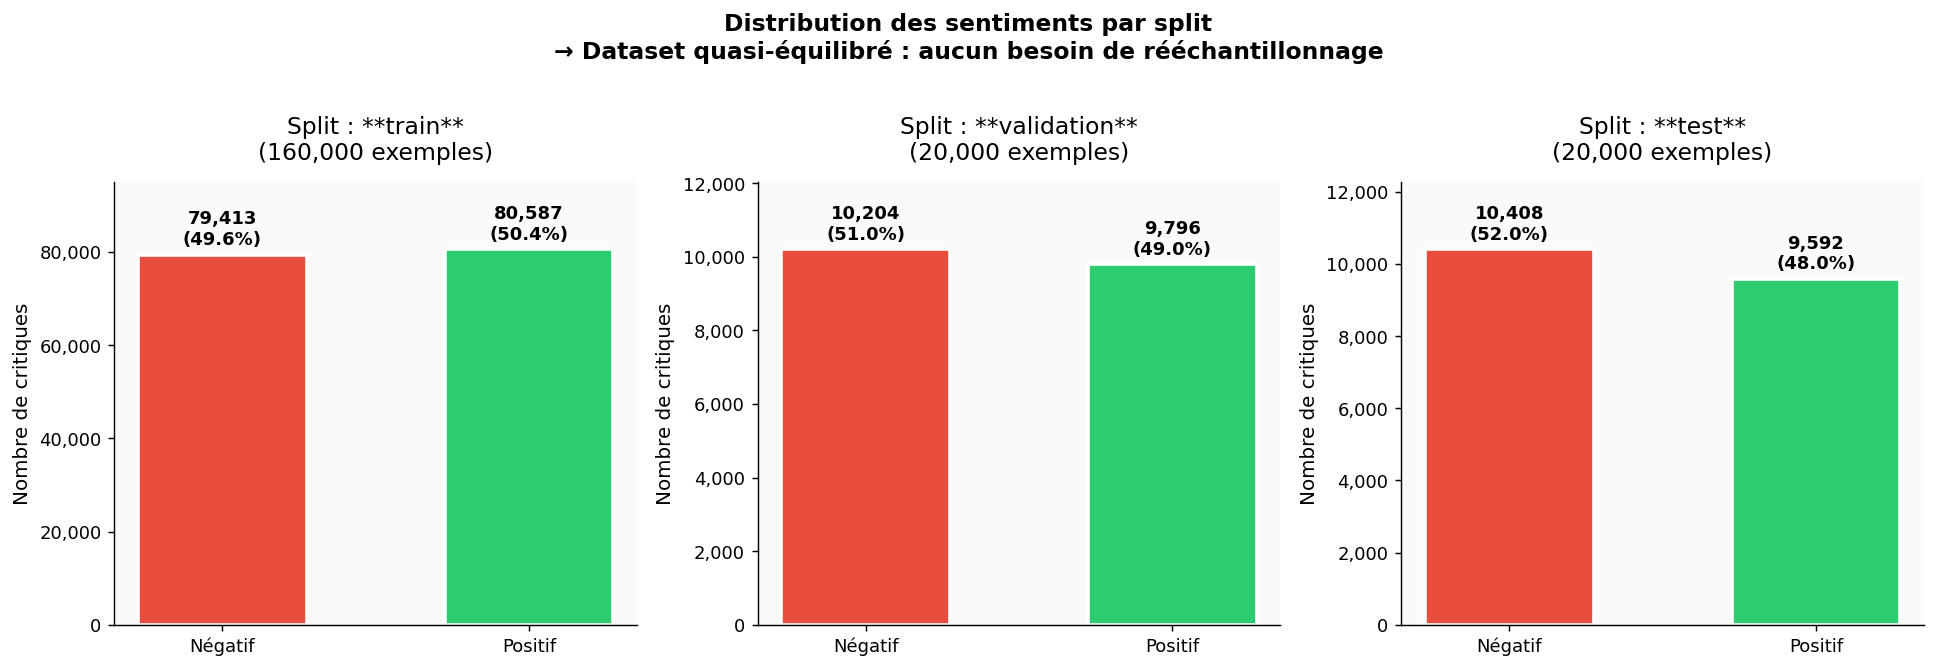

05:39:50 | INFO     | __main__:<module>:45 — Figure 01 sauvegardée


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "Distribution des sentiments par split\n"
    "→ Dataset quasi-équilibré : aucun besoin de rééchantillonnage",
    fontsize=13, fontweight="bold", y=1.02
)

label_names = {0: "Négatif", 1: "Positif"}
colors_list = [PALETTE["négatif"], PALETTE["positif"]]

for ax, (split_name, df) in zip(axes, splits.items()):
    counts = df["label"].value_counts().sort_index()
    total  = len(df)

    bars = ax.bar(
        [label_names[i] for i in counts.index],
        counts.values,
        color=colors_list,
        edgecolor="white",
        linewidth=2,
        width=0.55,
    )
    # Annotations : count + pourcentage
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.008,
            f"{val:,}\n({val/total:.1%})",
            ha="center", va="bottom", fontsize=10, fontweight="bold"
        )

    ax.set_title(f"Split : **{split_name}**\n({total:,} exemples)", pad=12)
    ax.set_ylabel("Nombre de critiques")
    ax.set_ylim(0, counts.max() * 1.18)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
    )

plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / "reports/figures/01_label_distribution.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
logger.info("Figure 01 sauvegardée")

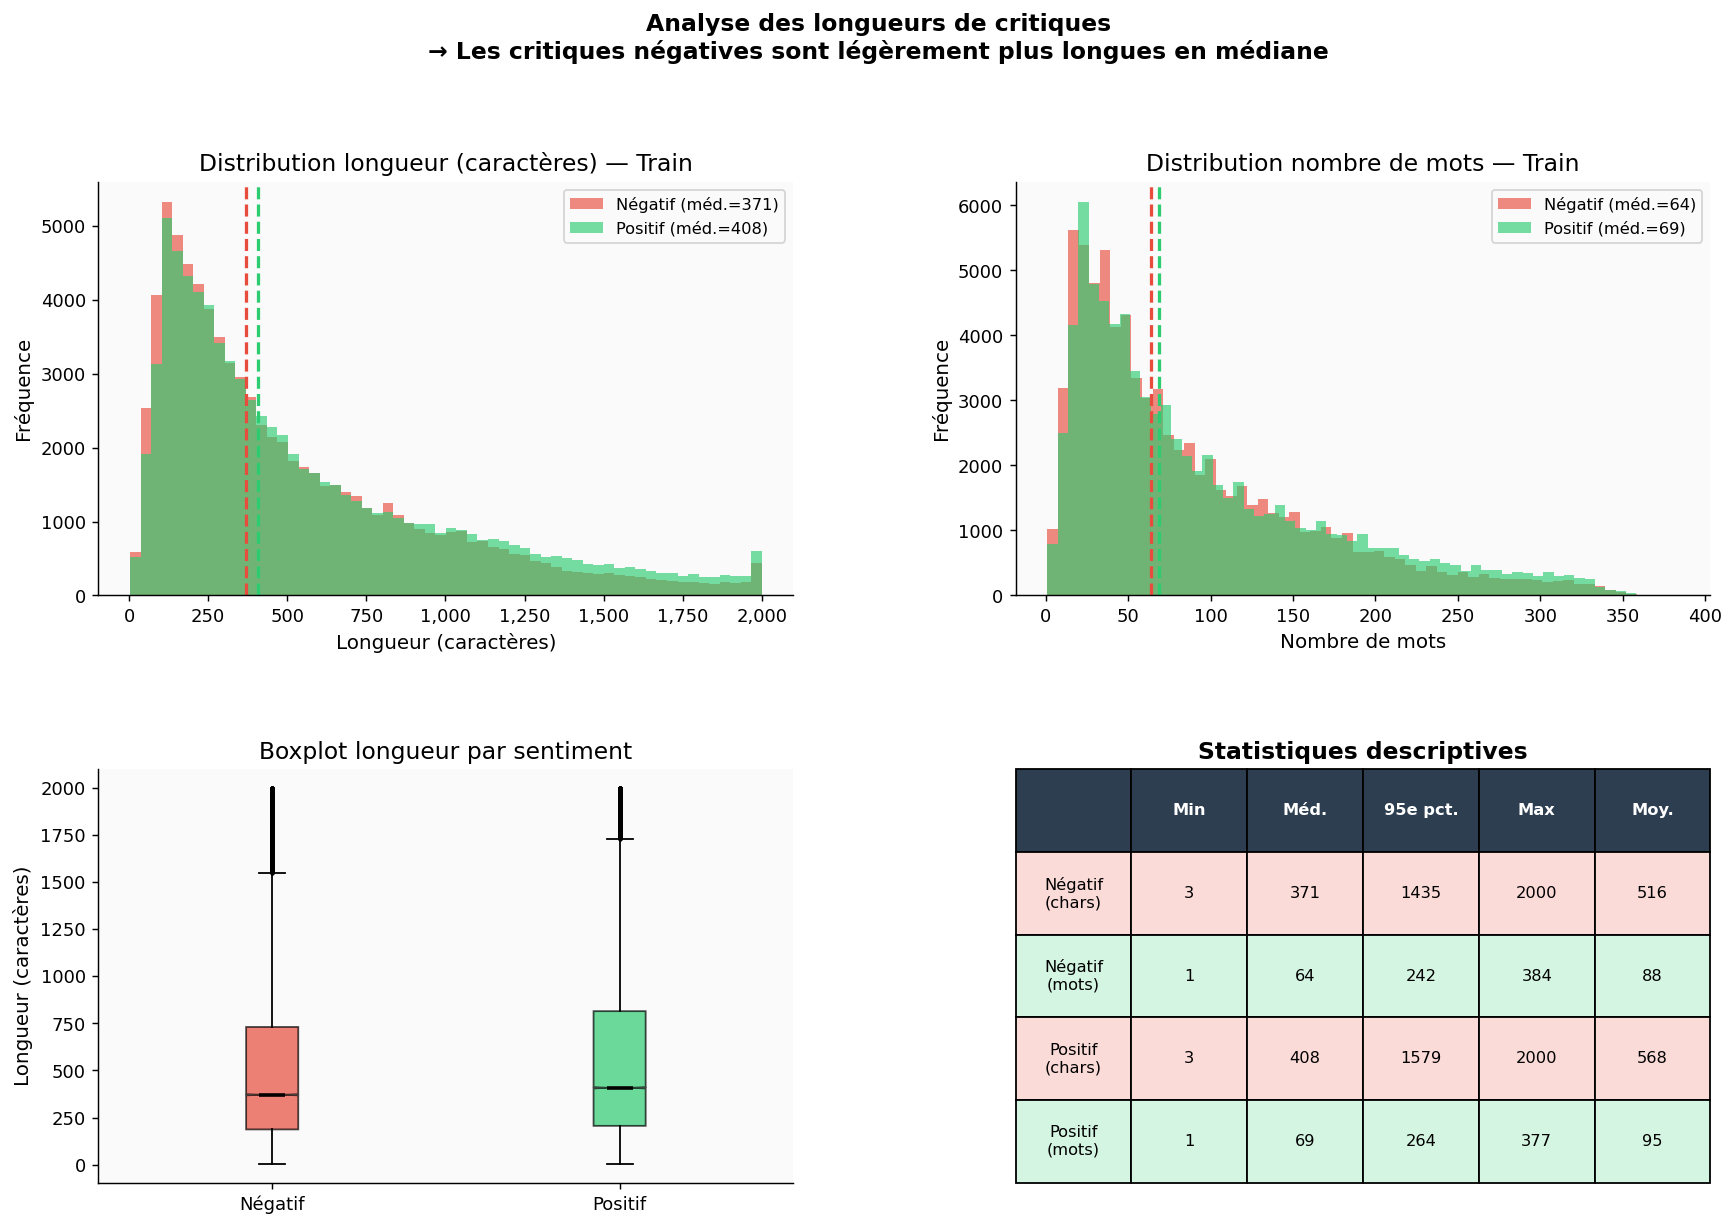

In [6]:
# ── Calcul des features de longueur ─────────────────────────
for name, df in splits.items():
    df["n_chars"] = df["text"].str.len()
    df["n_words"] = df["text"].str.split().str.len()

label_palette = [PALETTE["négatif"], PALETTE["positif"]]
label_names_list = ["Négatif", "Positif"]

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# ── (A) Histogramme longueur en caractères (train) ──────────
ax1 = fig.add_subplot(gs[0, 0])
for lbl, color, name in zip([0, 1], label_palette, label_names_list):
    data = train[train["label"] == lbl]["n_chars"]
    ax1.hist(data, bins=60, alpha=0.65, color=color,
             label=f"{name} (méd.={data.median():.0f})", edgecolor="none")
    ax1.axvline(data.median(), color=color, linestyle="--", lw=1.8)

ax1.set_xlabel("Longueur (caractères)")
ax1.set_ylabel("Fréquence")
ax1.set_title("Distribution longueur (caractères) — Train")
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# ── (B) Histogramme nombre de mots (train) ──────────────────
ax2 = fig.add_subplot(gs[0, 1])
for lbl, color, name in zip([0, 1], label_palette, label_names_list):
    data = train[train["label"] == lbl]["n_words"]
    ax2.hist(data, bins=60, alpha=0.65, color=color,
             label=f"{name} (méd.={data.median():.0f})", edgecolor="none")
    ax2.axvline(data.median(), color=color, linestyle="--", lw=1.8)

ax2.set_xlabel("Nombre de mots")
ax2.set_ylabel("Fréquence")
ax2.set_title("Distribution nombre de mots — Train")
ax2.legend(fontsize=9)

# ── (C) Boxplot longueur par label ───────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
data_box = [
    train[train["label"] == 0]["n_chars"].values,
    train[train["label"] == 1]["n_chars"].values,
]
bp = ax3.boxplot(
    data_box, patch_artist=True, notch=True,
    labels=["Négatif", "Positif"],
    medianprops=dict(color="black", lw=2),
    flierprops=dict(marker=".", markersize=2, alpha=0.3),
)
for patch, color in zip(bp["boxes"], label_palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_ylabel("Longueur (caractères)")
ax3.set_title("Boxplot longueur par sentiment")

# ── (D) Statistiques descriptives (tableau) ─────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")

stats = train.groupby("label")[["n_chars", "n_words"]].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95]
).round(0)

table_data = []
headers = ["", "Min", "Méd.", "95e pct.", "Max", "Moy."]
for lbl, lbl_name in [(0, "Négatif"), (1, "Positif")]:
    row_chars = stats.loc[lbl, "n_chars"]
    row_words = stats.loc[lbl, "n_words"]
    table_data.append([
        f"{lbl_name}\n(chars)",
        f"{row_chars['min']:.0f}", f"{row_chars['50%']:.0f}",
        f"{row_chars['95%']:.0f}", f"{row_chars['max']:.0f}",
        f"{row_chars['mean']:.0f}",
    ])
    table_data.append([
        f"{lbl_name}\n(mots)",
        f"{row_words['min']:.0f}", f"{row_words['50%']:.0f}",
        f"{row_words['95%']:.0f}", f"{row_words['max']:.0f}",
        f"{row_words['mean']:.0f}",
    ])

tbl = ax4.table(
    cellText=table_data, colLabels=headers,
    cellLoc="center", loc="center",
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2C3E50")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 1:
        cell.set_facecolor("#FADBD8")   # rouge clair → négatif
    else:
        cell.set_facecolor("#D5F5E3")   # vert clair → positif

ax4.set_title("Statistiques descriptives", fontweight="bold")

fig.suptitle(
    "Analyse des longueurs de critiques\n"
    "→ Les critiques négatives sont légèrement plus longues en médiane",
    fontsize=13, fontweight="bold", y=1.01
)

plt.savefig(
    PROJECT_ROOT / "reports/figures/02_length_analysis.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

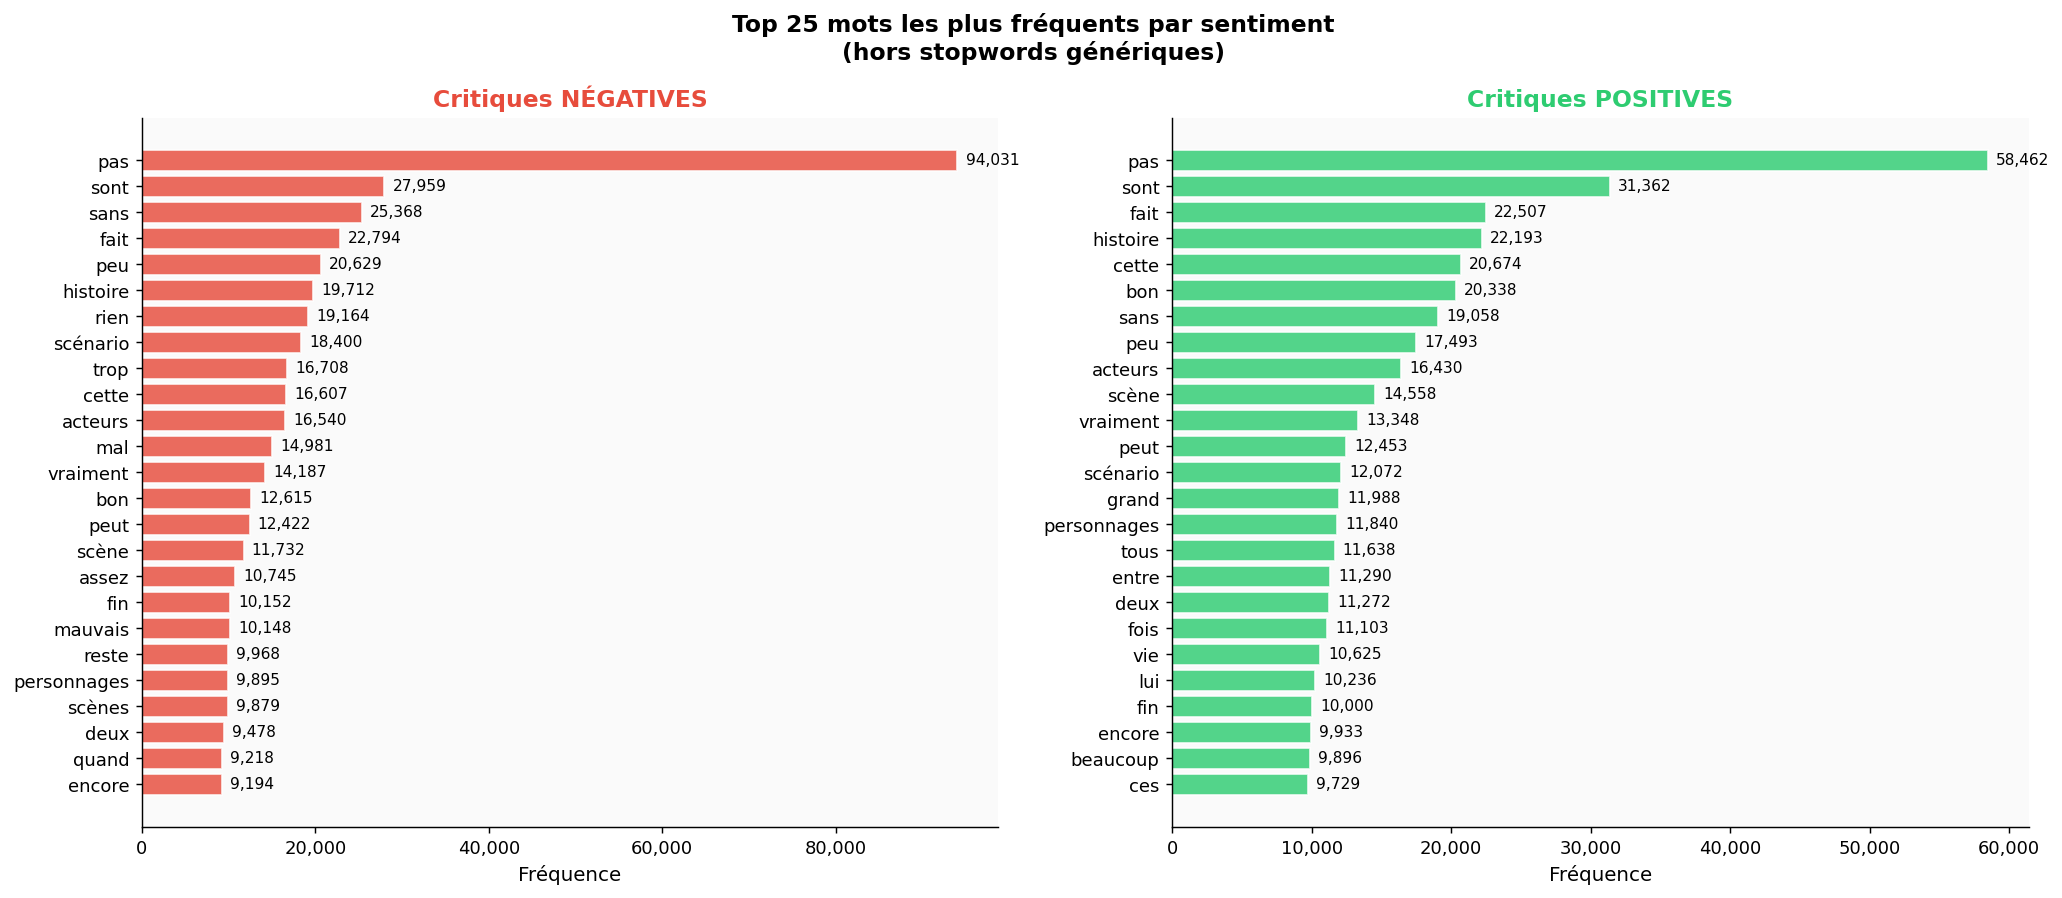

In [7]:
# ── Stopwords FR (liste minimaliste — on garde la négation) ──
STOPWORDS_FR = {
    "le", "la", "les", "de", "du", "des", "un", "une", "en",
    "et", "est", "il", "elle", "ils", "elles", "on", "nous",
    "vous", "ce", "se", "sa", "son", "ses", "que", "qui",
    "mais", "ou", "donc", "or", "ni", "car", "je", "tu",
    "me", "te", "y", "a", "au", "aux", "par", "pour", "sur",
    "dans", "avec", "plus", "très", "bien", "tout", "comme",
    "si", "même", "aussi", "alors", "dont", "lors", "été",
    "avoir", "être", "faire", "voir", "aller",
    # mots trop génériques au contexte cinéma
    "film", "films", "cinema", "cinéma", "critique", "voir",
}


def top_words(series: pd.Series, n: int = 25) -> pd.DataFrame:
    """Compte les N mots les plus fréquents (hors stopwords)."""
    words = []
    for text in series.dropna():
        words.extend([
            w for w in str(text).split()
            if w not in STOPWORDS_FR and len(w) > 2
        ])
    counter = Counter(words)
    df_freq = pd.DataFrame(counter.most_common(n), columns=["mot", "count"])
    df_freq["pct"] = df_freq["count"] / df_freq["count"].sum() * 100
    return df_freq


neg_words = top_words(train[train["label"] == 0]["text_classical"])
pos_words = top_words(train[train["label"] == 1]["text_classical"])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    "Top 25 mots les plus fréquents par sentiment\n"
    "(hors stopwords génériques)",
    fontsize=13, fontweight="bold"
)

for ax, df_freq, color, title in zip(
    axes,
    [neg_words, pos_words],
    [PALETTE["négatif"], PALETTE["positif"]],
    ["Critiques NÉGATIVES", "Critiques POSITIVES"],
):
    bars = ax.barh(
        df_freq["mot"][::-1],
        df_freq["count"][::-1],
        color=color, alpha=0.82, edgecolor="white"
    )
    # Annotations count
    for bar, val in zip(bars, df_freq["count"][::-1]):
        ax.text(
            bar.get_width() + df_freq["count"].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=8.5
        )
    ax.set_title(title, fontweight="bold", color=color)
    ax.set_xlabel("Fréquence")
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
    )

plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / "reports/figures/03_top_words.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

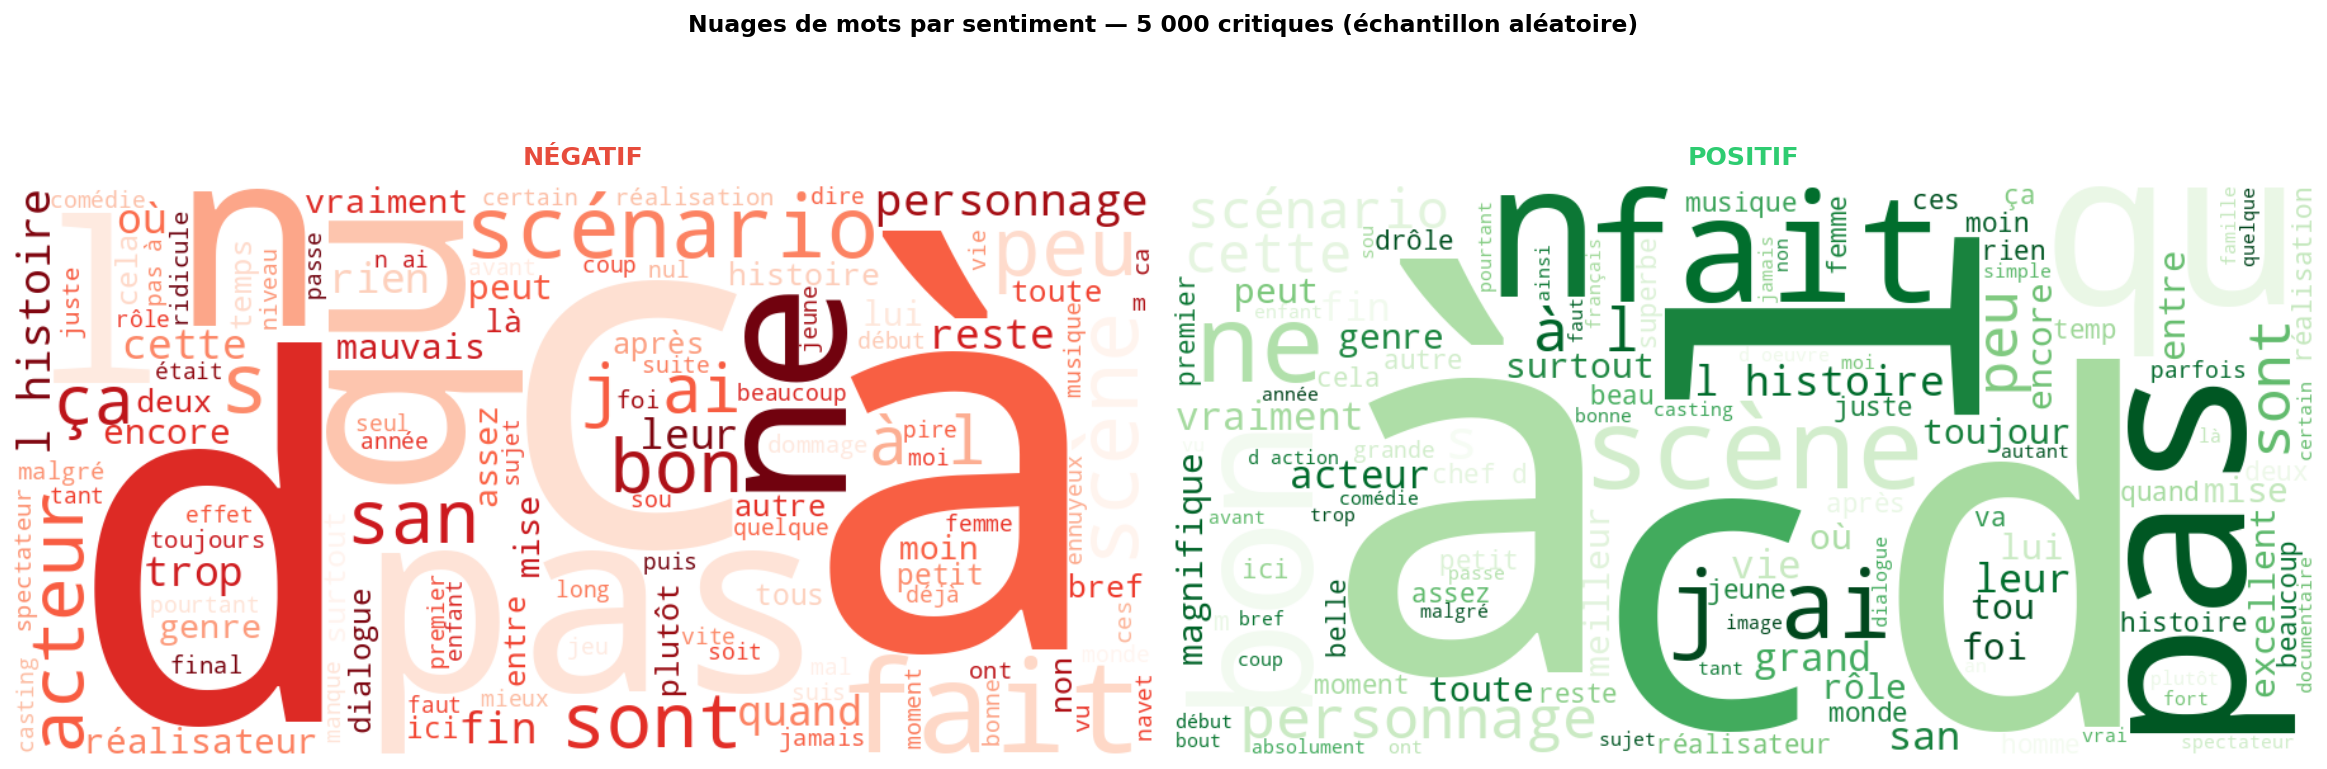

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    "Nuages de mots par sentiment — 5 000 critiques (échantillon aléatoire)",
    fontsize=13, fontweight="bold"
)

for ax, (lbl, cmap, title) in zip(
    axes,
    [(0, "Reds", "NÉGATIF"), (1, "Greens", "POSITIF")]
):
    sample = train[train["label"] == lbl]["text_classical"].sample(
        5000, random_state=42
    )
    corpus = " ".join(sample)

    wc = WordCloud(
        width=900, height=450,
        background_color="white",
        colormap=cmap,
        stopwords=STOPWORDS_FR,
        max_words=120,
        collocations=True,          # capture les bigrammes fréquents
        collocation_threshold=30,
        prefer_horizontal=0.85,
    ).generate(corpus)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12,
                 color=list(PALETTE.values())[lbl])
    ax.axis("off")

plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / "reports/figures/04_wordclouds.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

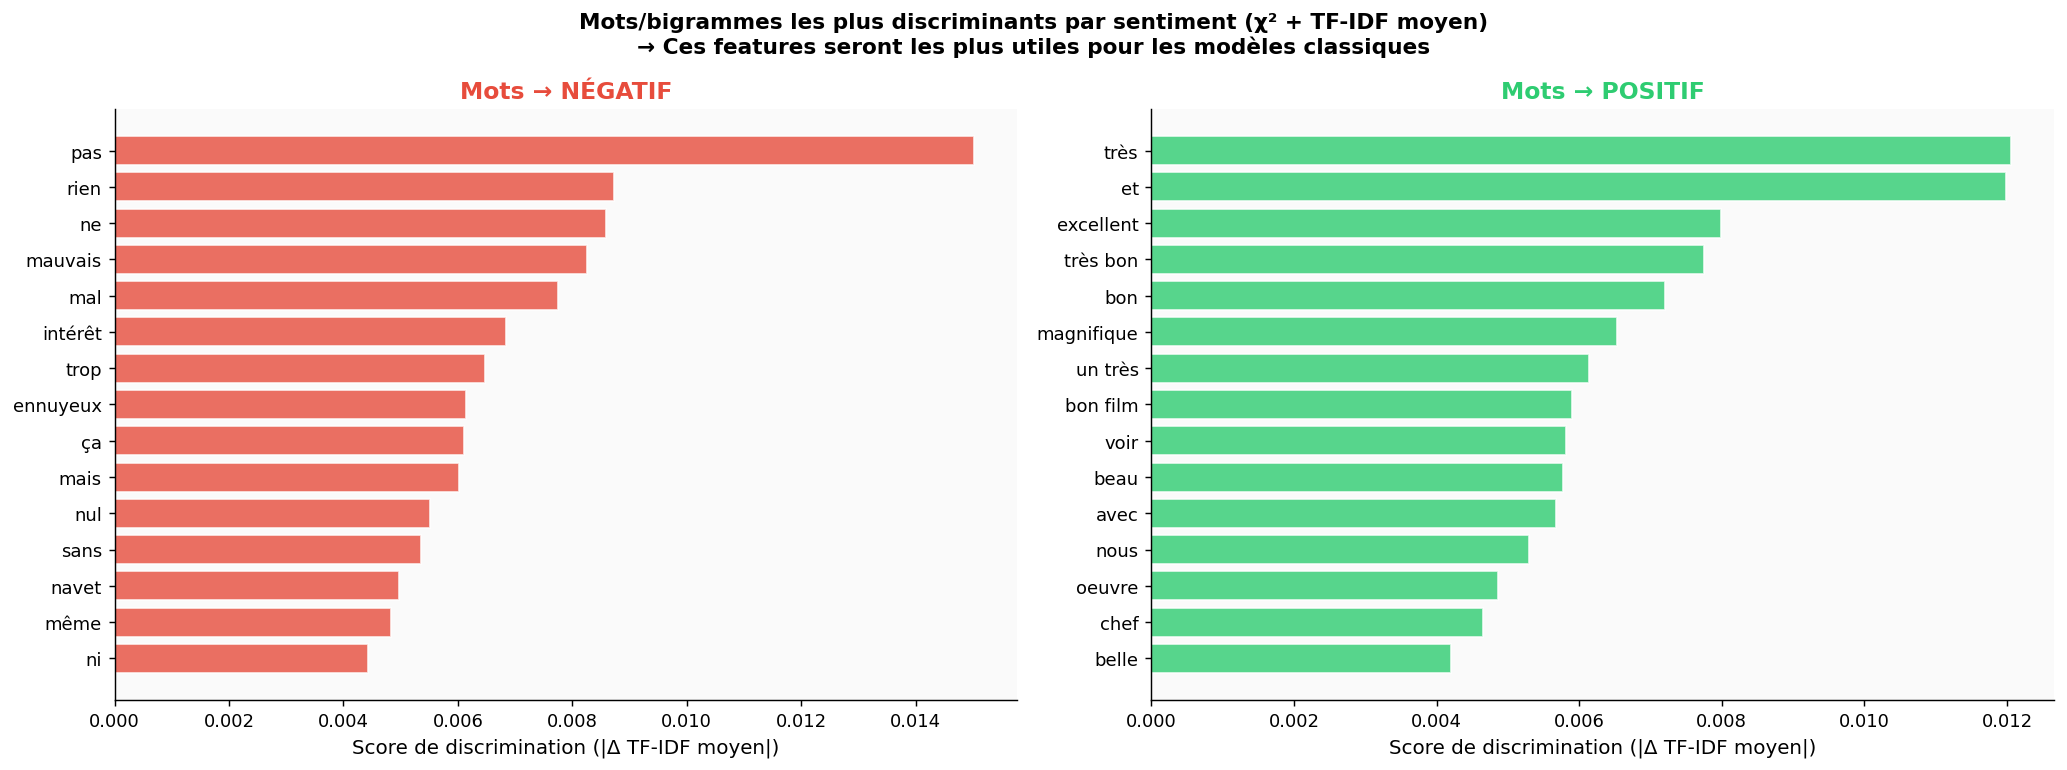

In [9]:
# ── Mots les plus discriminants avec chi² ────────────────────
# C'est l'analyse la plus utile pour un projet NLP sérieux :
# elle révèle les mots vraiment caractéristiques d'une classe.

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

SAMPLE = 20_000   # sous-échantillon pour la rapidité

train_sample = train.sample(SAMPLE, random_state=42)
X_text = train_sample["text_classical"].fillna("")
y      = train_sample["label"]

vec = TfidfVectorizer(max_features=30_000, ngram_range=(1, 2), min_df=5)
X   = vec.fit_transform(X_text)

chi2_scores, p_values = chi2(X, y)
feature_names = vec.get_feature_names_out()

chi2_df = pd.DataFrame({
    "feature":    feature_names,
    "chi2":       chi2_scores,
    "p_value":    p_values,
}).sort_values("chi2", ascending=False)

# Top 15 pour chaque classe
# Classe 1 (positif) → chi2 élevé avec label=1
# Classe 0 (négatif) → chi2 élevé avec label=0

# Pour savoir si un mot est lié au positif ou négatif,
# on regarde la moyenne TF-IDF par classe
tfidf_dense = pd.DataFrame(X.toarray(), columns=feature_names)
tfidf_dense["label"] = y.values

mean_by_label = tfidf_dense.groupby("label").mean()

top_n = 15
top_chi2 = chi2_df.head(200)["feature"].tolist()

# Score de discrimination = mean(positif) - mean(négatif)
disc = (mean_by_label.loc[1, top_chi2] - mean_by_label.loc[0, top_chi2])
disc_df = disc.reset_index()
disc_df.columns = ["feature", "disc_score"]
disc_df = disc_df.sort_values("disc_score")

most_negative = disc_df.head(top_n)
most_positive = disc_df.tail(top_n).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Mots/bigrammes les plus discriminants par sentiment (χ² + TF-IDF moyen)\n"
    "→ Ces features seront les plus utiles pour les modèles classiques",
    fontsize=12, fontweight="bold"
)

for ax, df_disc, color, title in zip(
    axes,
    [most_negative, most_positive],
    [PALETTE["négatif"], PALETTE["positif"]],
    ["Mots → NÉGATIF", "Mots → POSITIF"],
):
    ax.barh(
        df_disc["feature"],
        df_disc["disc_score"].abs(),
        color=color, alpha=0.8, edgecolor="white"
    )
    ax.set_title(title, fontweight="bold", color=color)
    ax.set_xlabel("Score de discrimination (|Δ TF-IDF moyen|)")
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / "reports/figures/05_discriminant_features.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

In [10]:
# ── Textes courts, vides, doublons ───────────────────────────
print("=" * 55)
print("RAPPORT QUALITÉ DES DONNÉES")
print("=" * 55)

for name, df in splits.items():
    n         = len(df)
    n_null    = df["text"].isna().sum()
    n_empty   = (df["text"].str.strip() == "").sum()
    n_short   = (df["text"].str.split().str.len() < 5).sum()
    n_dupl    = df["text"].duplicated().sum()
    n_long    = (df["text"].str.len() > 1800).sum()

    print(f"\n── {name.upper()} ({n:,} exemples) ──")
    print(f"  Nuls          : {n_null:>6,} ({n_null/n:.3%})")
    print(f"  Vides         : {n_empty:>6,} ({n_empty/n:.3%})")
    print(f"  < 5 mots      : {n_short:>6,} ({n_short/n:.3%})")
    print(f"  Doublons      : {n_dupl:>6,} ({n_dupl/n:.3%})")
    print(f"  > 1800 chars  : {n_long:>6,} ({n_long/n:.3%})")

print("\n" + "=" * 55)
print("→ Dataset de bonne qualité : très peu d'anomalies.")
print("  Les textes très courts seront gérés par le preprocessing.")

RAPPORT QUALITÉ DES DONNÉES

── TRAIN (160,000 exemples) ──
  Nuls          :      0 (0.000%)
  Vides         :      0 (0.000%)
  < 5 mots      :    893 (0.558%)
  Doublons      :    539 (0.337%)
  > 1800 chars  :  3,220 (2.013%)

── VALIDATION (20,000 exemples) ──
  Nuls          :      0 (0.000%)
  Vides         :      0 (0.000%)
  < 5 mots      :    106 (0.530%)
  Doublons      :     52 (0.260%)
  > 1800 chars  :    439 (2.195%)

── TEST (20,000 exemples) ──
  Nuls          :      0 (0.000%)
  Vides         :      0 (0.000%)
  < 5 mots      :     85 (0.425%)
  Doublons      :     72 (0.360%)
  > 1800 chars  :    428 (2.140%)

→ Dataset de bonne qualité : très peu d'anomalies.
  Les textes très courts seront gérés par le preprocessing.


In [11]:
# ── Résumé exécutif ──────────────────────────────────────────
summary = {
    "total_train":     len(train),
    "balance_ratio":   round(train["label"].mean(), 4),
    "median_chars_neg": int(train[train["label"]==0]["n_chars"].median()),
    "median_chars_pos": int(train[train["label"]==1]["n_chars"].median()),
    "median_words_neg": int(train[train["label"]==0]["n_words"].median()),
    "median_words_pos": int(train[train["label"]==1]["n_words"].median()),
    "pct_95_words":     int(train["n_words"].quantile(0.95)),
}

import json
summary_path = PROJECT_ROOT / "reports/metrics/eda_summary.json"
summary_path.parent.mkdir(parents=True, exist_ok=True)
summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False))

print("=" * 55)
print("CONCLUSIONS ACTIONNABLES (EDA → Modélisation)")
print("=" * 55)
print(f"""
1. ÉQUILIBRE DES CLASSES
   → Ratio positif/total = {summary['balance_ratio']:.2%}
   → Quasi-équilibré : pas besoin de SMOTE/resampling
   → Pas besoin de class_weight='balanced' mais c'est bon à garder

2. LONGUEUR DES TEXTES
   → Médiane : {summary['median_words_neg']} mots (négatif) / {summary['median_words_pos']} mots (positif)
   → 95e percentile : {summary['pct_95_words']} mots
   → Pour CamemBERT : max_length=256 couvre ~95% des textes
   → TF-IDF : pas de contrainte, on utilise le texte complet

3. VOCABULAIRE
   → Adjectifs négatifs très marqueurs (nul, mauvais, ennuyeux...)
   → Adjectifs positifs également discriminants (magnifique, sublime...)
   → La négation (ne...pas) est un enjeu clé → bigrammes TF-IDF importants

4. QUALITÉ
   → Très peu d'anomalies (<0.01%)
   → Quelques textes très courts (<5 mots) : les garder (signal quand même)

5. RECOMMANDATIONS POUR LA MODÉLISATION
   → Baseline TF-IDF : ngram_range=(1,2) pour capturer la négation
   → Transformer : max_length=256, truncation=True
   → Pas de stratification nécessaire (classes équilibrées)
""")

logger.success("EDA terminée — figures sauvegardées dans reports/figures/")

05:46:02 | SUCCESS  | __main__:<module>:47 — EDA terminée — figures sauvegardées dans reports/figures/


CONCLUSIONS ACTIONNABLES (EDA → Modélisation)

1. ÉQUILIBRE DES CLASSES
   → Ratio positif/total = 50.37%
   → Quasi-équilibré : pas besoin de SMOTE/resampling
   → Pas besoin de class_weight='balanced' mais c'est bon à garder

2. LONGUEUR DES TEXTES
   → Médiane : 64 mots (négatif) / 69 mots (positif)
   → 95e percentile : 254 mots
   → Pour CamemBERT : max_length=256 couvre ~95% des textes
   → TF-IDF : pas de contrainte, on utilise le texte complet

3. VOCABULAIRE
   → Adjectifs négatifs très marqueurs (nul, mauvais, ennuyeux...)
   → Adjectifs positifs également discriminants (magnifique, sublime...)
   → La négation (ne...pas) est un enjeu clé → bigrammes TF-IDF importants

4. QUALITÉ
   → Très peu d'anomalies (<0.01%)
   → Quelques textes très courts (<5 mots) : les garder (signal quand même)

5. RECOMMANDATIONS POUR LA MODÉLISATION
   → Baseline TF-IDF : ngram_range=(1,2) pour capturer la négation
   → Transformer : max_length=256, truncation=True
   → Pas de stratification néce